<a href="https://colab.research.google.com/github/saydulakbarmurad/pytorch/blob/main/torch_initial_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
#Create a random tensors of size (3, 4, 3)\
random_tensor = torch.rand(3, 4)
random_tensor

tensor([[0.2377, 0.2098, 0.7199, 0.4072],
        [0.2054, 0.8054, 0.9714, 0.0936],
        [0.3069, 0.5746, 0.3530, 0.2100]])

In [ ]:
#Create a random tensor with similar shape to an image tensor

random_image_size_tensor= torch.rand(size=(224, 224, 3))
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

#Zeros and Oners

In [ ]:
zeros = torch.zeros(size=(3, 4))
zeros

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [ ]:
zeros.dtype

torch.float32

In [ ]:
###Createing a range of tensors and tensors like

In [ ]:
one_to_ten= torch.arange(0, 10)
one_to_ten

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
torch.__version__

'2.10.0+cpu'

In [ ]:
#Createing tesnors like

ten_zeros = torch.zeros_like(input=one_to_ten)
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
import torch
import torch.nn as nn


x= torch.tensor([1, 2, 3, 4], dtype=torch.float32)
y = torch.tensor([2, 4, 5, 7], dtype=torch.float32)

w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

def forward(x):
  return w*x

learning_rate = 0.01
n_iters = 100

loss = nn.MSELoss()

optimizer = torch.optim.SGD([w], lr=learning_rate)

for epoch in range(n_iters):
  y_pred = forward(x)

  l = loss(y, y_pred)

  l.backward()

  optimizer.step()

  optimizer.zero_grad()

  if epoch % 10 == 0:
    print(f'epoch {epoch+1}: w = {w:.3f}, loss={l:.8f}')


print(f'Prediction after training: f(5) = {forward(5):.3f}')

epoch 1: w = 0.265, loss=23.50000000
epoch 11: w = 1.471, loss=0.99896282
epoch 21: w = 1.708, loss=0.12683289
epoch 31: w = 1.755, loss=0.09302968
epoch 41: w = 1.764, loss=0.09171948
epoch 51: w = 1.766, loss=0.09166870
epoch 61: w = 1.767, loss=0.09166673
epoch 71: w = 1.767, loss=0.09166667
epoch 81: w = 1.767, loss=0.09166668
epoch 91: w = 1.767, loss=0.09166667
Prediction after training: f(5) = 8.833


In [ ]:
import torch
import torch.nn as nn


x= torch.tensor([[1], [2], [3], [4]], dtype=torch.float32)
y = torch.tensor([[2], [4], [5], [7]], dtype=torch.float32)

x_test = torch.tensor([5], dtype=torch.float32)

n_samples, n_features=x.shape

print(n_samples, n_features)

input_size=n_features
output_size=n_features

# model = nn.Linear(input_size, output_size)

class LinearRegression(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(LinearRegression, self).__init__()
    self.lin = nn.Linear(input_dim, output_dim)

  def forward(self, x):
    return self.lin(x)

model = LinearRegression(input_size, output_size)

print(f'Prediction before training: f(5) = {model(x_test).item():.3f}')

learning_rate = 0.01
n_iters = 100

loss = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(n_iters):
  y_pred = model(x)

  l = loss(y, y_pred)

  l.backward()

  optimizer.step()

  optimizer.zero_grad()

  if epoch % 10 == 0:
    [w, b]=model.parameters()
    print(f'epoch {epoch+1}: w = {w[0][0].item():.3f}, loss={l:.8f}')


print(f'Prediction after training: f(5) = {model(x_test).item():.3f}')

4 1
Prediction before training: f(5) = -3.103
epoch 1: w = -0.263, loss=42.83090210
epoch 11: w = 1.237, loss=1.16492045
epoch 21: w = 1.480, loss=0.08645223
epoch 31: w = 1.521, loss=0.05810686
epoch 41: w = 1.530, loss=0.05695650
epoch 51: w = 1.533, loss=0.05653400
epoch 61: w = 1.535, loss=0.05615325
epoch 71: w = 1.537, loss=0.05579506
epoch 81: w = 1.539, loss=0.05545778
epoch 91: w = 1.541, loss=0.05514017
Prediction after training: f(5) = 8.381


epoch: 10, loss=4394.5293
epoch: 20, loss=3279.8418
epoch: 30, loss=2472.8809
epoch: 40, loss=1888.0931
epoch: 50, loss=1463.9059
epoch: 60, loss=1155.9426
epoch: 70, loss=932.1776
epoch: 80, loss=769.4697
epoch: 90, loss=651.0773
epoch: 100, loss=564.8763


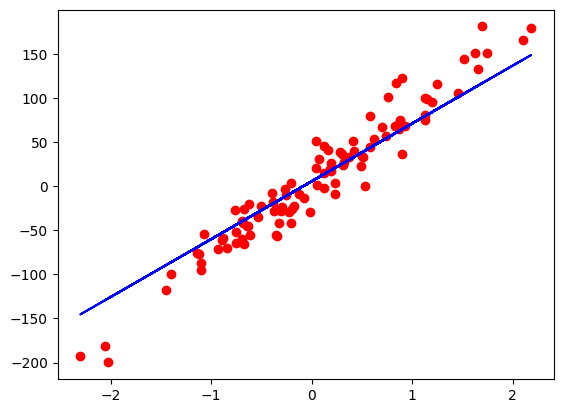

In [5]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets

import matplotlib.pyplot as plt


x_numpy, y_numpy = datasets.make_regression(n_samples=100, n_features =1, noise=20, random_state=1)

x = torch.from_numpy(x_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))

y = y.view(y.shape[0], 1)

n_samples, n_features = x.shape

input_size= n_features
output_size = 1
model = nn.Linear(input_size, output_size)

learning_rate = 0.01
criterion = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

num_epochs = 100

for epoch in range(num_epochs):
  y_predicted = model(x)
  loss = criterion(y_predicted, y)
  loss.backward()
  optimizer.step()

  optimizer.zero_grad()

  if (epoch+1) % 10 ==0:
    print(f'epoch: {epoch+1}, loss={loss.item():.4f}')


predicted = model(x).detach().numpy()
plt.plot(x_numpy, y_numpy, 'ro')
plt.plot(x_numpy, predicted, 'b')
plt.show()
